## NB5｜最小 BERT：從 nanoGPT 到雙向 MLM（選讀分支）

**前置理論：** [`theory/01`](../theory/01a-prerequisites-intuition.md) → [`02`](../theory/02-attention-intuition.md) → [`03a`](../theory/03a-transformer-architecture.md) → [`07`](../theory/07-bert-encoder-only.md)

**本 Notebook 目標：**
- 把 NB4 的 `Head` **刪掉一行 `masked_fill`**，就從因果（GPT）變成雙向（BERT）
- 把訓練目標從 next-token 換成 **MLM（克漏字）**：隨機遮 15%、只在被遮位置算 loss
- 加上 BERT 的輸入表示：`[CLS]` / `[SEP]` 與 token + segment + position 三種 embedding
- 訓練後做「遮一個字、模型填回來」的 demo
- **附錄（選讀）**：載入 HuggingFace 預訓練 BERT 對照（需額外安裝，預設不執行）

> 對照 [`NB4-nanoGPT.ipynb`](NB4-nanoGPT.ipynb)：模型骨架幾乎一字不差，差別只有**遮罩**與**目標**兩處，正是 [`theory/07`](../theory/07-bert-encoder-only.md) 的主軸。

---

# 🧩 最小 BERT — 同一個 Block，換遮罩換目標

## 1. 匯入套件

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import urllib.request
import os
import random

print(f'PyTorch 版本: {torch.__version__}')
print(f'使用裝置: {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch 版本: 2.12.0
使用裝置: cpu


## 2. 超參數設定

沿用 NB4 的輕量驗證版，確保 CPU 可快速跑完。

In [2]:
# ── 快速驗證版（CPU ~30 秒）─────────────────────────────
batch_size    = 16      # 每次訓練的批次大小
block_size    = 64      # 序列長度（含 [CLS]/[SEP]）
max_iters     = 300     # 訓練總步數
eval_interval = 100     # 每幾步評估一次
eval_iters    = 20      # 評估時平均幾個 batch
learning_rate = 3e-4
mlm_prob      = 0.15    # 被挑中當預測目標的比例（BERT 用 15%）

# ── 模型架構（輕量版）───────────────────────────────────
n_embd  = 64    # embedding 維度
n_head  = 2     # attention heads 數量
n_layer = 2     # transformer block 層數
dropout = 0.2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(1337)
random.seed(1337)
print('超參數設定完成 ✓')

超參數設定完成 ✓


## 3. 資料與字元級 Tokenizer（加入特殊 token）

沿用 NB4 的莎士比亞文本。與 NB4 唯一不同：詞彙表最前面保留 4 個**特殊 token**（`[PAD]` / `[CLS]` / `[SEP]` / `[MASK]`），對應 [`theory/07`](../theory/07-bert-encoder-only.md) §3。

In [3]:
# 下載莎士比亞資料集（與 NB4 相同來源；輸出寫到 data/ 不污染根目錄）
data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, 'input.txt')

url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
if not os.path.exists(data_path):
    print('下載資料集...')
    urllib.request.urlretrieve(url, data_path)

with open(data_path, 'r', encoding='utf-8') as f:
    text = f.read()

print(f'資料集大小: {len(text):,} 字元')

資料集大小: 1,115,394 字元


In [4]:
# ── 特殊 token 放在 id 0..3，真實字元從 4 開始 ────────────
PAD_ID, CLS_ID, SEP_ID, MASK_ID = 0, 1, 2, 3
N_SPECIAL = 4

chars      = sorted(list(set(text)))
vocab_size = len(chars) + N_SPECIAL

stoi = {ch: i + N_SPECIAL for i, ch in enumerate(chars)}   # 字元 → 整數
itos = {i + N_SPECIAL: ch for i, ch in enumerate(chars)}
itos.update({PAD_ID: '[PAD]', CLS_ID: '[CLS]', SEP_ID: '[SEP]', MASK_ID: '[MASK]'})

encode = lambda s: [stoi[c] for c in s]                 # 只編碼真實字元
decode = lambda ids: ''.join(itos[i] for i in ids)      # 特殊 token 也能還原

# 切分訓練 / 驗證集（90% / 10%）—— 存的是「純字元」的 id，特殊 token 在建 batch 時才加
data = torch.tensor(encode(text), dtype=torch.long)
n    = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print(f'詞彙表大小: {vocab_size}（含 {N_SPECIAL} 個特殊 token）')
print(f'訓練集: {len(train_data):,} tokens　驗證集: {len(val_data):,} tokens')

詞彙表大小: 69（含 4 個特殊 token）
訓練集: 1,003,854 tokens　驗證集: 111,540 tokens


## 4. MLM 批次建構

每個樣本組成 `[CLS] 句A [SEP] 句B [SEP]`（示範句子對輸入與 segment embedding），再依 [`theory/07`](../theory/07-bert-encoder-only.md) §2 的規則遮罩：

- 隨機挑 **15%** 的非特殊位置當預測目標
- 其中 **80%** 換 `[MASK]`、**10%** 換隨機字、**10%** 保持原字
- `labels` 只在被挑中的位置放正解，其餘填 `-100`（`cross_entropy` 的 `ignore_index`，不計損失）

In [5]:
CONTENT_LEN = block_size - 3          # 扣掉 [CLS] 與兩個 [SEP]
HALF        = CONTENT_LEN // 2        # 句A長度；句B取剩下的

def make_example(span):
    """span: 長度 CONTENT_LEN 的字元 id list → (input_ids, segment_ids, labels)"""
    A, B = span[:HALF], span[HALF:]
    ids  = [CLS_ID] + A + [SEP_ID] + B + [SEP_ID]              # 長度 = block_size
    seg  = [0] * (2 + len(A)) + [1] * (len(B) + 1)             # 句A=0，句B=1
    sep1 = 1 + len(A)                                          # 第一個 [SEP] 的位置
    special_pos = {0, sep1, block_size - 1}                    # 這些位置永不遮

    labels = [-100] * block_size
    for p in range(block_size):
        if p in special_pos:
            continue
        if random.random() < mlm_prob:
            labels[p] = ids[p]                                 # 記下正解
            r = random.random()
            if r < 0.8:
                ids[p] = MASK_ID                               # 80% → [MASK]
            elif r < 0.9:
                ids[p] = random.randint(N_SPECIAL, vocab_size - 1)  # 10% → 隨機字
            # 其餘 10% 保持原字不變
    return ids, seg, labels

def get_batch(split):
    src = train_data if split == 'train' else val_data
    X, S, Y = [], [], []
    for _ in range(batch_size):
        i    = random.randint(0, len(src) - CONTENT_LEN - 1)
        span = src[i:i + CONTENT_LEN].tolist()
        ids, seg, labels = make_example(span)
        X.append(ids); S.append(seg); Y.append(labels)
    to = lambda a: torch.tensor(a, dtype=torch.long, device=device)
    return to(X), to(S), to(Y)

# 檢視一個樣本：被遮的位置看得到 [MASK]，labels 只在那些位置有值
xb, sb, yb = get_batch('train')
print(f'input  shape: {tuple(xb.shape)}　segment shape: {tuple(sb.shape)}　labels shape: {tuple(yb.shape)}')
masked = (yb[0] != -100).sum().item()
print(f'第 0 個樣本被遮 {masked} / {block_size} 個位置（約 {masked/block_size:.0%}）')
print('input 還原：', decode(xb[0].tolist()).replace(chr(10), ' '))

input  shape: (16, 64)　segment shape: (16, 64)　labels shape: (16, 64)
第 0 個樣本被遮 7 / 64 個位置（約 11%）
input 還原： [CLS]to account this world b[MASK][MASK] hell[SEP], Until m[MASK] [MASK]is-shaped trunk tha[SEP]


## 5. 模型：把 NB4 的 `Head` 刪掉一行就是 BERT

下面 `BidirectionalHead` 與 NB4 的 `Head`（[`04b`](../theory/04b-nanogpt-walkthrough.md) §1）**逐字對照**——唯一差別是**沒有** `masked_fill` 那行，於是注意力從下三角變成全連接（雙向），對應 [`theory/07`](../theory/07-bert-encoder-only.md) §1。`MultiHeadAttention` / `FeedForward` / `Block` 與 NB4 完全相同。

In [6]:
class BidirectionalHead(nn.Module):
    """單一雙向 Self-Attention Head（= NB4 的 Head 拿掉 causal mask）"""

    def __init__(self, head_size):
        super().__init__()
        self.key     = nn.Linear(n_embd, head_size, bias=False)
        self.query   = nn.Linear(n_embd, head_size, bias=False)
        self.value   = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        # ← 注意：這裡不再 register_buffer('tril', ...)，因為不需要因果遮罩

    def forward(self, x):
        B, T, C = x.shape  # 注意 C = n_embd，不是 head_size
        k = self.key(x)
        q = self.query(x)
        d_k = k.shape[-1]                           # d_k = head_size（與 NB4 相同）
        wei = q @ k.transpose(-2, -1) * d_k**-0.5   # (B, T, T)
        # ← NB4 在這裡有一行 wei = wei.masked_fill(tril == 0, -inf)；BERT 版刪掉它 = 雙向
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v


class MultiHeadAttention(nn.Module):
    """多頭 Attention（與 NB4 相同，只是 Head 換成 BidirectionalHead）"""

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads   = nn.ModuleList([BidirectionalHead(head_size) for _ in range(num_heads)])
        self.proj    = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    """Position-wise FFN（與 NB4 完全相同）"""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

print('BidirectionalHead / MultiHeadAttention / FeedForward 定義完成 ✓')

BidirectionalHead / MultiHeadAttention / FeedForward 定義完成 ✓


In [7]:
class Block(nn.Module):
    """Transformer Block（與 NB4 完全相同：Pre-LN + Residual）"""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

print('Block 定義完成 ✓')

Block 定義完成 ✓


模型主體 `BertMLM`：與 NB4 的 `GPT` 相比有兩個差別——(1) 多一個 **segment embedding**（[`theory/07`](../theory/07-bert-encoder-only.md) §3 的三種 embedding 相加）；(2) 輸出頭是 **MLM head**，損失用 `ignore_index=-100` 只算被遮位置（§2.2）。

In [8]:
class BertMLM(nn.Module):
    """最小 BERT：雙向 encoder + MLM head"""

    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding    = nn.Embedding(vocab_size, n_embd)
        self.segment_embedding  = nn.Embedding(2, n_embd)          # ← 句A / 句B（NB4 沒有）
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks   = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f     = nn.LayerNorm(n_embd)
        self.mlm_head = nn.Linear(n_embd, vocab_size)             # 預測每個位置的原字

    def forward(self, idx, seg, targets=None):
        B, T = idx.shape
        tok = self.token_embedding(idx)                                  # (B,T,C)
        sgm = self.segment_embedding(seg)                                # (B,T,C)
        pos = self.position_embedding(torch.arange(T, device=device))    # (T,C)
        x = tok + sgm + pos                                              # 三種 embedding 相加

        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.mlm_head(x)                                        # (B,T,vocab)

        loss = None
        if targets is not None:
            # 只在被遮位置（labels != -100）算 cross-entropy
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T),
                                   ignore_index=-100)
        return logits, loss


model = BertMLM(vocab_size).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'模型初始化完成 ✓　總參數量: {total_params:,} ({total_params/1e6:.2f}M)')

模型初始化完成 ✓　總參數量: 112,837 (0.11M)


## 6. 訓練

MLM 每個序列只有約 15% 位置有學習訊號（[`theory/07`](../theory/07-bert-encoder-only.md) §2.3），所以初始 loss 與收斂節奏和 NB4 略有不同，但趨勢一樣是往下走。

In [9]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, S, Y = get_batch(split)
            _, loss = model(X, S, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_losses, val_losses, steps_log = [], [], []

print(f'開始訓練（{max_iters} steps）...\n')
print(f'{"Step":>6}  {"Train Loss":>10}  {"Val Loss":>10}')
print('-' * 32)

for step in range(max_iters):
    if step % eval_interval == 0 or step == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())
        steps_log.append(step)
        print(f'{step:>6}  {losses["train"]:>10.4f}  {losses["val"]:>10.4f}')

    xb, sb, yb = get_batch('train')
    _, loss = model(xb, sb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print('\n訓練完成 ✓')

開始訓練（300 steps）...

  Step  Train Loss    Val Loss
--------------------------------
     0      4.3308      4.3474
   100      3.3686      3.3844
   200      3.3144      3.3545
   299      3.2389      3.3531

訓練完成 ✓


## 7. 視覺化訓練曲線

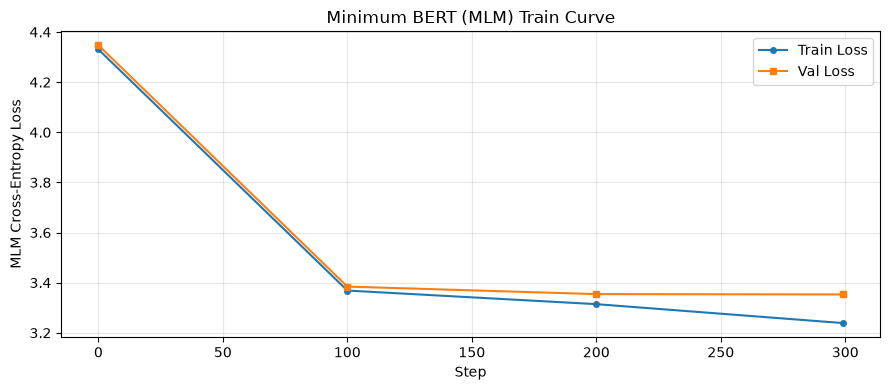

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(steps_log, train_losses, label='Train Loss', marker='o', markersize=4)
plt.plot(steps_log, val_losses,   label='Val Loss',   marker='s', markersize=4)
plt.xlabel('Step'); plt.ylabel('MLM Cross-Entropy Loss')
plt.title('Minimum BERT (MLM) Train Curve')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

## 8. 克漏字 Demo：遮一個字，模型填回來

這正是 BERT 與 GPT 的分野——GPT 只能**往下續寫**（NB4 §7），BERT 能用**左右文**把中間挖掉的字補回來。

In [11]:
@torch.no_grad()
def predict_masked(sentence, mask_pos, top_k=5):
    """把 sentence 第 mask_pos 個字元換成 [MASK]，讓模型預測它"""
    assert len(sentence) + 2 <= block_size, '句子太長，請縮短或調大 block_size'
    ids = [CLS_ID] + encode(sentence) + [SEP_ID]
    seg = [0] * len(ids)
    mp  = mask_pos + 1                       # +1 因為前面多了 [CLS]
    true_char = sentence[mask_pos]
    ids[mp] = MASK_ID

    model.eval()
    x = torch.tensor([ids], dtype=torch.long, device=device)
    s = torch.tensor([seg], dtype=torch.long, device=device)
    logits, _ = model(x, s)
    probs = F.softmax(logits[0, mp], dim=-1)

    # 取機率最高的候選，略過特殊 token
    topv, topi = torch.topk(probs, top_k + N_SPECIAL)
    preds = [(itos[i.item()], v.item()) for i, v in zip(topi, topv) if i.item() >= N_SPECIAL][:top_k]

    masked_view = sentence[:mask_pos] + '_' + sentence[mask_pos+1:]
    print(f'輸入（_ 為被遮）：{masked_view!r}　正解：{true_char!r}')
    print('模型預測 top-{}:'.format(top_k))
    for ch, p in preds:
        hit = '  ← 正解' if ch == true_char else ''
        print(f'   {ch!r:>6}  {p:6.1%}{hit}')

# 隨便挑幾個常見片語試試（字元級模型，能學到的是字母層級的規律）
predict_masked('to be or not to be', 3)     # 遮 'e'
print()
predict_masked('the king is dead', 4)       # 遮 'k'

輸入（_ 為被遮）：'to _e or not to be'　正解：'b'
模型預測 top-5:
      ' '   21.0%
      'e'   10.1%
      't'    7.6%
      'o'    5.0%
      'h'    4.8%

輸入（_ 為被遮）：'the _ing is dead'　正解：'k'
模型預測 top-5:
      ' '   20.8%
      'e'    9.8%
      't'    7.5%
      'o'    5.7%
      'r'    5.1%


## 9. 儲存模型

In [12]:
torch.save({
    'model_state_dict': model.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'vocab_size': vocab_size,
    'stoi': stoi,
    'itos': itos,
}, os.path.join(data_dir, 'mini_bert_checkpoint.pt'))
print(f'模型已儲存至 {os.path.join(data_dir, "mini_bert_checkpoint.pt")} ✓')

模型已儲存至 data/mini_bert_checkpoint.pt ✓


## 附錄（選讀）：載入 HuggingFace 預訓練 BERT

上面手刻的最小 BERT 是為了**理解機制**——字元級、參數量極小，填空能力有限。
真正好用的 BERT 是在海量語料上預訓練好的，可用 [HuggingFace `transformers`](https://huggingface.co/docs/transformers) 一行載入。

這段是**選讀延伸**，需要額外安裝與下載模型權重，因此**預設不執行**（`RUN_HF = False`）。
想對照真實預訓練 BERT 時：

```bash
pip install transformers
```

再把下方 `RUN_HF` 改成 `True`。它示範兩件事：
1. **MLM 克漏字**（`fill-mask`）——和我們手刻的目標一模一樣，只是換成 word-piece、真實權重
2. **句子分類**（`sentiment-analysis`）——[`theory/07`](../theory/07-bert-encoder-only.md) §5「接 head 微調」的現成產物

> 讀者可自行往下延伸：換成 `Sentence-BERT`（`sentence-transformers`）做句子嵌入與語意檢索，
> 就接上了 [`theory/00`](../theory/00-learning-path.md) §5 的 RAG 分支。

In [14]:
RUN_HF = False   # ← 想對照真實預訓練 BERT 時改成 True（需 pip install transformers 並下載權重）

if RUN_HF:
    try:
        from transformers import pipeline

        # 1) MLM 克漏字：和我們手刻的訓練目標相同
        fill = pipeline('fill-mask', model='bert-base-uncased')
        for r in fill('The capital of France is [MASK].')[:3]:
            print(f"{r['token_str']:>12}  {r['score']:.3f}")

        print()
        # 2) 句子分類：encoder + 一個分類 head 微調的成品
        clf = pipeline('sentiment-analysis')
        print(clf('This movie was absolutely wonderful!'))
    except Exception as e:
        print('HuggingFace 段落執行失敗（可忽略）：', repr(e))
else:
    print('（選讀）RUN_HF=False，未載入 HuggingFace。')
    print('把 RUN_HF 改成 True（並先 pip install transformers）即可對照真實預訓練 BERT。')

（選讀）RUN_HF=False，未載入 HuggingFace。
把 RUN_HF 改成 True（並先 pip install transformers）即可對照真實預訓練 BERT。


## 小結：GPT vs BERT，差別只有兩處

| | NB4（GPT）| NB5（BERT，本檔）|
|---|---|---|
| Head | 有 `masked_fill`（因果、下三角）| **刪掉那行**（雙向、全連接）|
| 訓練目標 | next-token（每個位置都算）| MLM（只算被遮的 15%）|
| 輸入 embedding | token + position | token + **segment** + position |
| 特殊 token | 無 | `[CLS]` / `[SEP]` / `[MASK]` |
| 輸出頭 | LM head（接下一字）| MLM head（填被遮的字）|
| 天生擅長 | 生成 | 理解 / 填空 |

其餘（多頭注意力、殘差、LayerNorm、FFN、Pre-LN Block）**兩者共用**。
理論全貌見 [`theory/07-bert-encoder-only.md`](../theory/07-bert-encoder-only.md)。